<a href="https://colab.research.google.com/github/mtalhak003/AI-ML-Deep-Learning/blob/main/Decision_Tree_Classification_Using_Entropy_and_Pruning_on_the_Student_Performance_Dataset.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.metrics import accuracy_score

In [4]:
from google.colab import files
uploaded = files.upload()

Saving student-mat.csv to student-mat.csv


In [6]:
df = pd.read_csv("student-mat.csv")

df.head()

,school,sex,age,address,famsize,Pstatus,Medu,Fedu,Mjob,Fjob,...,famrel,freetime,goout,Dalc,Walc,health,absences,G1,G2,G3
0,GP,F,18,U,GT3,A,4,4,at_home,teacher,...,4,3,4,1,1,3,6,5,6,6
1,GP,F,17,U,GT3,T,1,1,at_home,other,...,5,3,3,1,1,3,4,5,5,6
2,GP,F,15,U,LE3,T,1,1,at_home,other,...,4,3,2,2,3,3,10,7,8,10
3,GP,F,15,U,GT3,T,4,2,health,services,...,3,2,2,1,1,5,2,15,14,15
4,GP,F,16,U,GT3,T,3,3,other,other,...,4,3,2,1,2,5,4,6,10,10


In [7]:
print(df.shape)
print(df.info())

(395, 33)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 395 entries, 0 to 394
Data columns (total 33 columns):
 #   Column      Non-Null Count  Dtype 
---  ------      --------------  ----- 
 0   school      395 non-null    object
 1   sex         395 non-null    object
 2   age         395 non-null    int64 
 3   address     395 non-null    object
 4   famsize     395 non-null    object
 5   Pstatus     395 non-null    object
 6   Medu        395 non-null    int64 
 7   Fedu        395 non-null    int64 
 8   Mjob        395 non-null    object
 9   Fjob        395 non-null    object
 10  reason      395 non-null    object
 11  guardian    395 non-null    object
 12  traveltime  395 non-null    int64 
 13  studytime   395 non-null    int64 
 14  failures    395 non-null    int64 
 15  schoolsup   395 non-null    object
 16  famsup      395 non-null    object
 17  paid        395 non-null    object
 18  activities  395 non-null    object
 19  nursery     395 non-null    object
 20  

In [8]:
df = pd.get_dummies(df, drop_first=True)

In [10]:
print(df.columns)

Index(['age', 'Medu', 'Fedu', 'traveltime', 'studytime', 'failures', 'famrel',
       'freetime', 'goout', 'Dalc', 'Walc', 'health', 'absences', 'G1', 'G2',
       'G3', 'school_MS', 'sex_M', 'address_U', 'famsize_LE3', 'Pstatus_T',
       'Mjob_health', 'Mjob_other', 'Mjob_services', 'Mjob_teacher',
       'Fjob_health', 'Fjob_other', 'Fjob_services', 'Fjob_teacher',
       'reason_home', 'reason_other', 'reason_reputation', 'guardian_mother',
       'guardian_other', 'schoolsup_yes', 'famsup_yes', 'paid_yes',
       'activities_yes', 'nursery_yes', 'higher_yes', 'internet_yes',
       'romantic_yes'],
      dtype='object')


In [11]:
df["result"] = df["G3"].apply(lambda x: 1 if x >= 10 else 0)

In [12]:
df = df.drop(["G1","G2","G3"], axis=1)

In [13]:
X = df.drop("result", axis=1)
y = df["result"]

In [14]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [15]:
from sklearn.tree import DecisionTreeClassifier

dt = DecisionTreeClassifier(
    criterion="entropy",
    max_depth=4,
    random_state=42
)

dt.fit(X_train, y_train)

DecisionTreeClassifier(criterion='entropy', max_depth=4, random_state=42)

In [16]:
from sklearn.metrics import accuracy_score

y_pred = dt.predict(X_test)

print("Accuracy:", accuracy_score(y_test, y_pred))

Accuracy: 0.7468354430379747


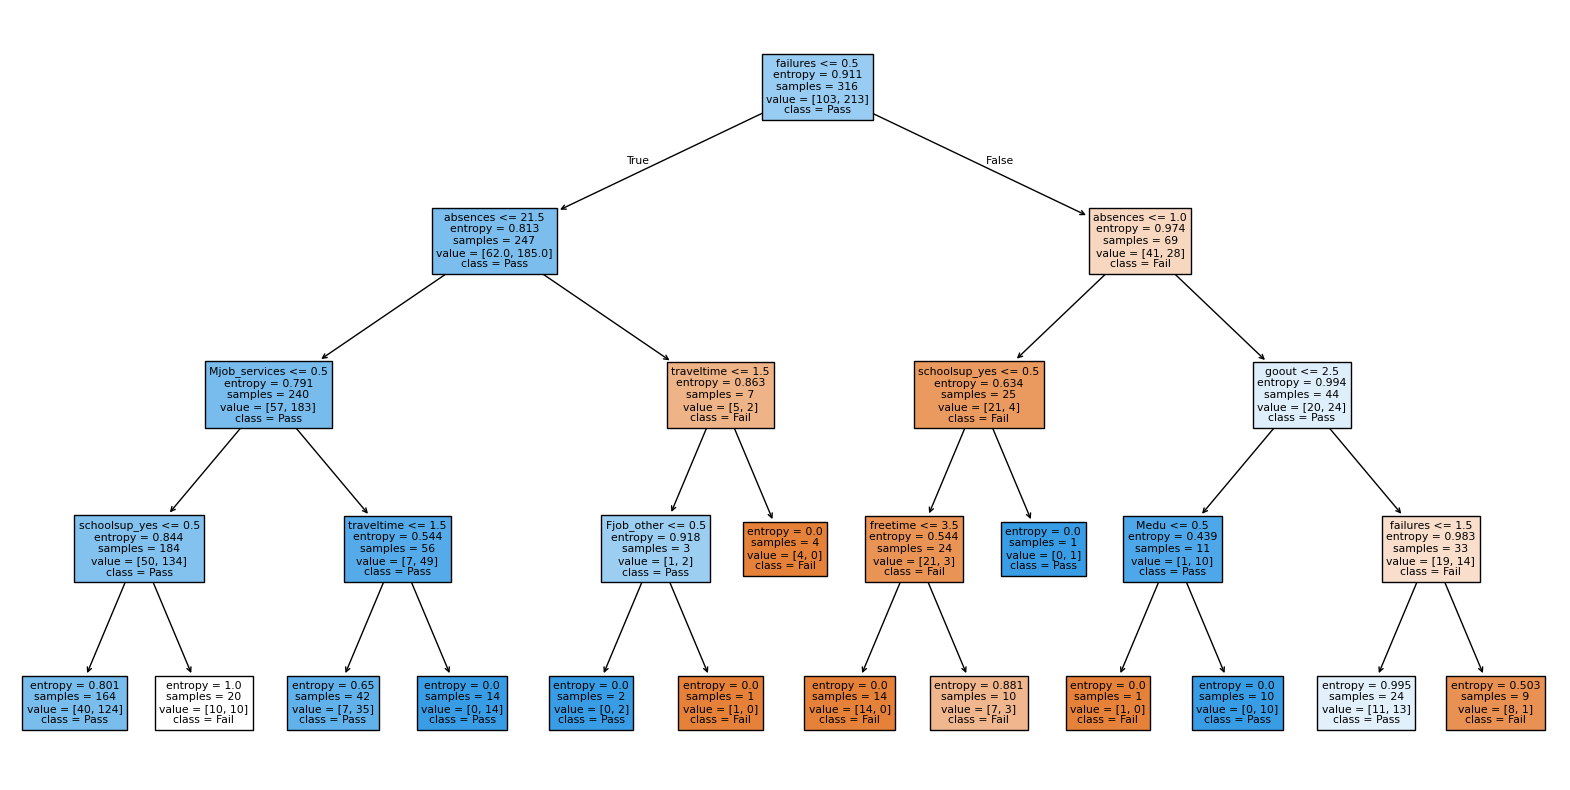

In [17]:
import matplotlib.pyplot as plt
from sklearn.tree import plot_tree

plt.figure(figsize=(20,10))

plot_tree(
    dt,
    feature_names=X.columns,
    class_names=["Fail","Pass"],
    filled=True
)

plt.show()

In [18]:
path = dt.cost_complexity_pruning_path(X_train, y_train)
ccp_alphas = path.ccp_alphas

In [19]:
pruned_tree = DecisionTreeClassifier(
    criterion="entropy",
    ccp_alpha=0.01
)

pruned_tree.fit(X_train, y_train)

DecisionTreeClassifier(ccp_alpha=0.01, criterion='entropy')

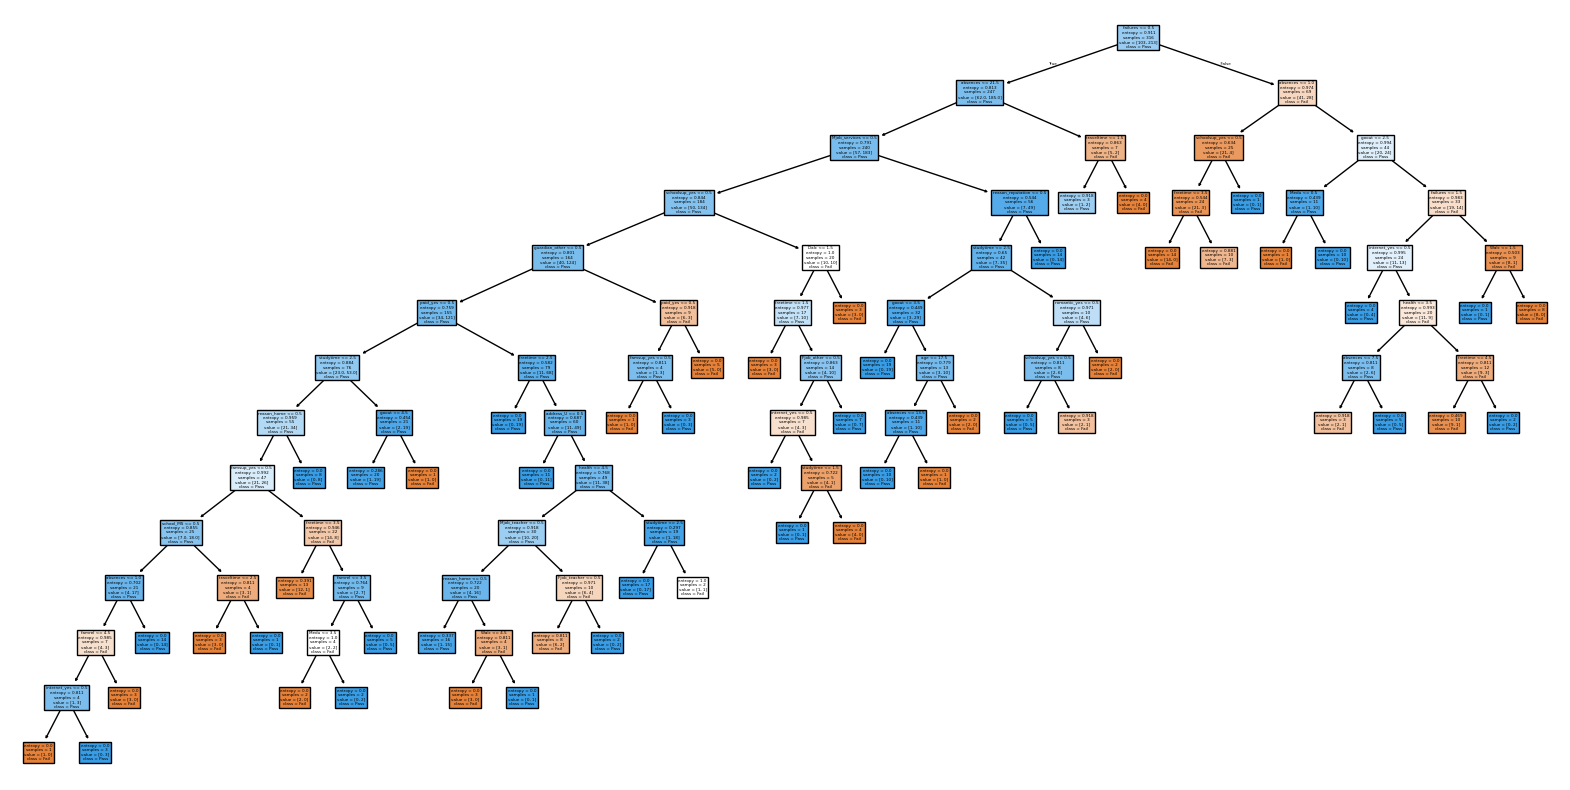

In [20]:
plt.figure(figsize=(20,10))

plot_tree(
    pruned_tree,
    feature_names=X.columns,
    class_names=["Fail","Pass"],
    filled=True
)

plt.show()

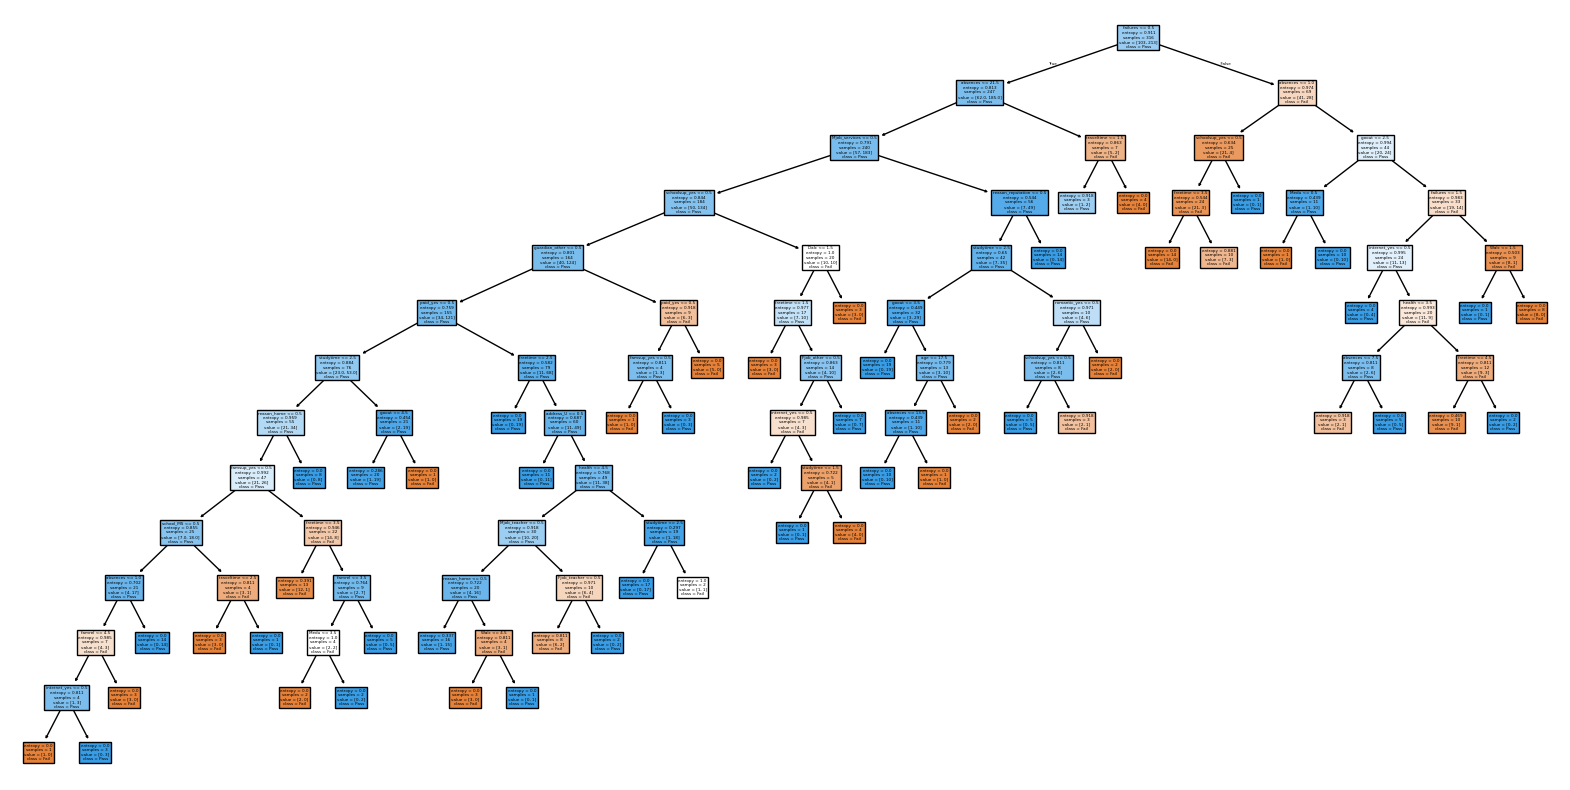

In [21]:
plt.figure(figsize=(20,10))

plot_tree(
    pruned_tree,
    feature_names=X.columns,
    class_names=["Fail","Pass"],
    filled=True
)

plt.show()

In [22]:
df_reduced = df.sample(frac=0.9, random_state=42)

In [23]:
X2 = df_reduced.drop("result", axis=1)
y2 = df_reduced["result"]

X_train2, X_test2, y_train2, y_test2 = train_test_split(
    X2, y2, test_size=0.2, random_state=42
)

dt2 = DecisionTreeClassifier(
    criterion="entropy",
    max_depth=4
)

dt2.fit(X_train2, y_train2)

DecisionTreeClassifier(criterion='entropy', max_depth=4)

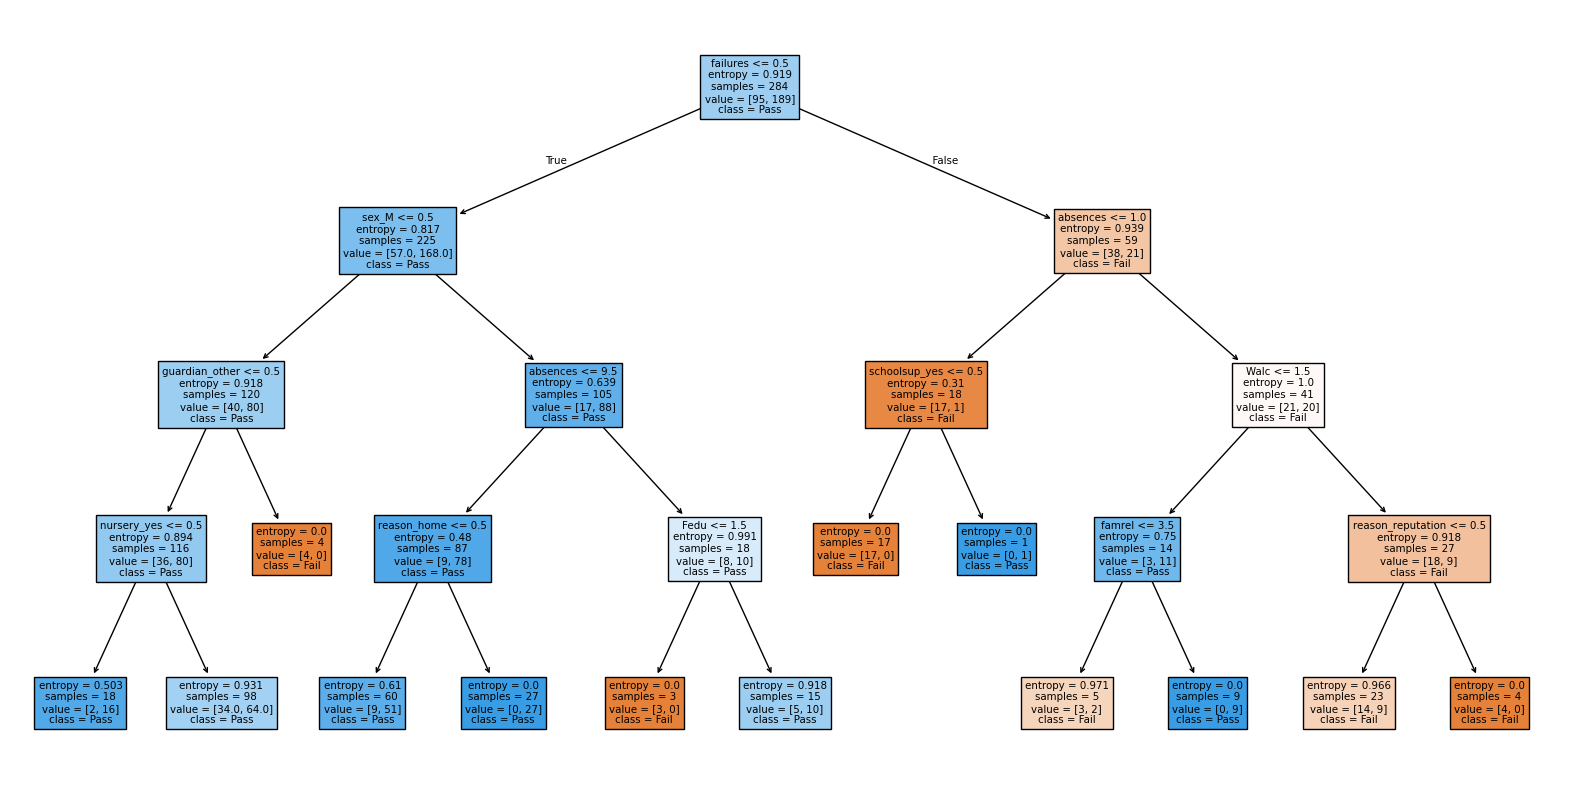

In [24]:
plt.figure(figsize=(20,10))

plot_tree(
    dt2,
    feature_names=X2.columns,
    class_names=["Fail","Pass"],
    filled=True
)

plt.show()